In [1]:
# import numpy as np
import pandas as pd
from collections import Counter
from functools import reduce
import matplotlib.pyplot as plt
# Matplotlib中设置字体-黑体，解决Matplotlib中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决Matplotlib坐标轴负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('ggplot')
%matplotlib inline

# 统计数据

1.统计“工资平均收入”和“分数”两组数据

In [2]:
import pandas as pd
bank = pd.read_csv("data\\test\\bank.csv")
salary = bank[bank['工资收入标记'] == 1]
avg_salary = salary.groupby(['new_user_id'])["交易金额"].agg(["mean"])
avg_salary.columns = ["工资平均收入"]
avg_salary.reset_index(inplace=True)
avg_salary


,new_user_id,工资平均收入
0,00375b8a7a62da4f578f4f4464fc4228,44.964550
1,00872649357929f1f3d7fafbe484810b,46.415984
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812
3,02419b54629f540d3430e6ba8230aac4,45.600048
4,024c12c231362aa4206c001674abe30f,40.380961
...,...,...
551,fdfcea9217eac320f5d2e30a58f356fa,42.958105
552,fe000bc1c6325b6df010187cca665a1e,46.980840
553,fed554907bfead73a15b053ecec59e11,47.292812
554,fee3ee14f7b2e42e86746d19115ef14a,47.061820


In [3]:
overdue = pd.read_csv("data\\test\\overdue.csv")
overdue.drop(['Unnamed: 0'],axis=1,inplace=True)
overdue=overdue[['new_user_id','分数']]
overdue

,new_user_id,分数
0,eddcaa8984f8db5199ec28323efb18a4,51.846690
1,65b01fba105ee82613babff7c88929c5,70.242250
2,968083a2d1a7e6b5b85a66b0bc412830,73.397476
3,18aeed58fd39a58cc1430a3a417ed7a9,55.463276
4,bae4896cea4a34616ae3babca11439ae,54.754932
...,...,...
9995,aef033946bf25d056d1bc01f28b397d5,52.179243
9996,b3b457750eb9d6941fce9d1258003879,57.013629
9997,f5858c654e97bd9d03fb9131a2a12dd8,52.002452
9998,6989c7588f79c186a0895e6e9a70efa8,55.380466


In [4]:
merge = pd.merge(avg_salary, overdue, on='new_user_id')
merge

,new_user_id,工资平均收入,分数
0,00375b8a7a62da4f578f4f4464fc4228,44.964550,81.809911
1,00872649357929f1f3d7fafbe484810b,46.415984,76.203618
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812,83.483392
3,02419b54629f540d3430e6ba8230aac4,45.600048,84.831173
4,024c12c231362aa4206c001674abe30f,40.380961,79.597737
...,...,...,...
551,fdfcea9217eac320f5d2e30a58f356fa,42.958105,85.427484
552,fe000bc1c6325b6df010187cca665a1e,46.980840,83.284661
553,fed554907bfead73a15b053ecec59e11,47.292812,84.522937
554,fee3ee14f7b2e42e86746d19115ef14a,47.061820,86.948580


# 相关系数

 $r=\frac{\sum_{i=1}^{n}(x_{i}-\overline{x})(y_{i}-\overline{y})}{\sqrt{\sum_{i=1}^{n}{(x_{i}-\overline{x})}^{2}}\sqrt{\sum_{i=1}^{n}{(y_{i}-\overline{y})}^{2}}}$

2.计算两组数据的相关系数，相关系数请自行编程实现，不要使用corr函数。并将结果与corr函数的结果对比。

In [5]:
x, y = merge['工资平均收入'], merge['分数']
meanx = merge['工资平均收入'].mean()
meany = merge['分数'].mean()

In [6]:
upper = sum( (x - meanx) * (y - meany) )
lower = (sum((x - meanx) ** 2) ** 0.5) * (sum((y - meany) ** 2) ** 0.5)
r = upper / lower
print(f"相关系数：{r}") #使用“{}”作为占位符，将变量的值插入到字符串中

相关系数：0.13633187791178358


In [7]:
x.corr(y)

0.13633187791178372

# 线性回归方法一：解方程

$\theta_{0}=\frac{\sum_{i=1}^{n}(x_{i})^{2}\sum_{i=1}^{n}y_{i}-\sum_{i=1}^{n}x_{i}\sum_{i=1}^{n}x_{i}y_{i}}{n\sum_{i=1}^{n}(x_{i})^{2}-(\sum_{i=1}^{n}x_{i})^{2}}$

$\theta_{1}=\frac{n\sum_{i=1}^{n}x_{i}y_{i}-\sum_{i=1}^{n}x_{i}\sum_{i=1}^{n}y_{i}}{n\sum_{i=1}^{n}(x_{i})^{2}-(\sum_{i=1}^{n}x_{i})^{2}}$

3.按照给出的线性回归流程，使用解方程的方法编程计算𝜃_0和𝜃_1

In [8]:
xs1 = sum(x)
xs2 = sum(x ** 2)
ys1 = sum(y)
ys2 = sum(y ** 2)
xy  = sum(x * y)
print(f"xs1 = {xs1}; xs2 = {xs2};\nys1 = {ys1}; ys2 = {ys2};\nxy = {xy};")

xs1 = 25189.996409839492; xs2 = 1143956.5803103254;
ys1 = 45400.88523263889; ys2 = 3714755.8789129523;
xy = 2057534.710793386;


In [9]:
n = len(x)
theta_0 = (xs2 * ys1 - xs1 * xy) / (n * xs2 - xs1 ** 2)
theta_1 = (n * xy - xs1 * ys1) / (n * xs2 - xs1 ** 2)
print(f'截距 theta_0：{theta_0}\n斜率 theta_1：{theta_1}')

截距 theta_0：71.37882475616765
斜率 theta_1：0.22684634706723292


# 线性回归方法二：网格搜索

4.使用网格搜索的方法编程计算𝜃_0和𝜃_1

我们进行如下设置：

斜率搜索范围都是  [−50,50]  ，步数  200  ，因此搜索步长自动计算为  (50−(−50))/200=0.5

截距搜索范围都是  [−50,50]  ，步数  200  ，因此搜索步长自动计算为  (50−(−50))/200=0.5

因此这里会计算  200×200=40000  次。不宜把步数设置太多，这将导致程序一直在执行。

 误差的方程是:$MSE=\sum_{i=1}^{n}(\theta_{0}+\theta_{1}x_{i}-y_{i})^{2}$

In [10]:
xlim0, xlim1, xcnt = -50, 50, 200 
ylim0, ylim1, ycnt = -50, 50, 200 
xstep, ystep = (xlim1 - xlim0) / xcnt, (ylim1 - ylim0) / ycnt

"""
这样搜索出的值未必是最优的
你可以试试调整上面这些参数
比如设置：
xlim0, xlim1, xcnt = -50, 50, 100
ylim0, ylim1, ycnt = -50, 50, 100
就是在 [-50, -49, -48, ... , 49,50] 里搜索截距，在  [-50, -49, -48, ... , 49,50] 里搜索斜率

注意，计算量与 xcnt 、 ycnt 成正比，如果这两个变量设置得太大，你的程序可能卡死在这里。
"""

def cal_error(theta_0, theta_1):
    return sum((theta_0 + theta_1 * x - y) ** 2)

best_theta_0, best_theta_1, best_error = 0, 0, 2e9
from tqdm import tqdm
for t1 in tqdm([xlim0 + i * xstep for i in range(xcnt + 1)]):
    for t2 in [ylim0 + i * ystep for i in range(ycnt + 1)]:
        error = cal_error(t1, t2)
        if error < best_error:
            best_error = error
            best_theta_0 = t1
            best_theta_1 = t2

print(f"best_error: {best_error}, best_theta_0: {best_theta_0}, best_theta_1: {best_theta_1}")

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:17<00:00, 11.38it/s]

best_error: 8979.153572138313, best_theta_0: 36.5, best_theta_1: 1.0


# 利用梯度下降法求解$min_x(x-1)^2$的最优解

Starting gradient descent...
Initial Error at x = 0 is error = 1
x=0.02
x=0.039599999999999996
x=0.058808
x=0.07763184000000001
x=0.0960792032
x=0.114157619136
x=0.13187446675328002
x=0.14923697741821443
x=0.16625223786985013
x=0.18292719311245315
x=0.19926864925020407
x=0.2152832762652
x=0.230977610739896
x=0.2463580585250981
x=0.2614308973545961
x=0.2762022794075042
x=0.2906782338193541
x=0.304864669142967
x=0.31876737576010766
x=0.3323920282449055
x=0.34574418768000736
x=0.3588293039264072
x=0.37165271784787907
x=0.3842196634909215
x=0.3965352702211031
x=0.408604564816681
x=0.4204324735203474
x=0.43202382404994044
x=0.44338334756894165
x=0.4545156806175628
x=0.46542536700521153
x=0.4761168596651073
x=0.4865945224718052
x=0.4968626320223691
x=0.5069253793819217
x=0.5167868717942833
x=0.5264511343583976
x=0.5359221116712297
x=0.5452036694378051
x=0.554299596049049
x=0.563213604128068
x=0.5719493320455066
x=0.5805103454045965
x=0.5889001384965045
x=0.5971221357265744
x=0.60517969301204

Text(0.5, 1.0, 'Cost Function Over Iteration')

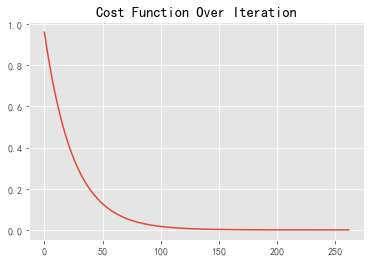

In [11]:
def cost_Function(x):
    return (x-1)**2
 
def gradientDescent(x,alpha,iters):
    
    a_0 = 2e9
    cutoff=1e-6
    # Array to store values of error for analysis
    hist = []
    # Perform Gradient Descent for iters
    for _ in range(iters):
        # Perform Gradient Descent
        # Initialize Values of Gradients
        gradient = 2*(x-1)
        x = x - alpha*gradient
        print(f'x={x}')
        # Calculate the change in error with new values of "theta_1" and "theta_0"
        a = cost_Function(x)
        if abs(a-a_0) < cutoff:
           break
        hist.append(a)
        a_0 = a
    return [x,hist]
 
 
# Learning Rate
lr = 1e-2
initial_x = 0
# Number of Iterations
iterations = 1000
print("Starting gradient descent...")
 
print("Initial Error at x = {0} is error = {1}".format
      (initial_x, cost_Function(initial_x)))
 
 
[x_toy,hist] = gradientDescent(initial_x, lr, iterations)
 
print('Values obtained after {0} iterations are x = {1}'.format
      (iterations,x_toy))
 
fig,ax = plt.subplots()
ax.plot(hist)
ax.set_title('Cost Function Over Iteration')

# 线性回归方法三：使用梯度下降法，寻找最优的参数值

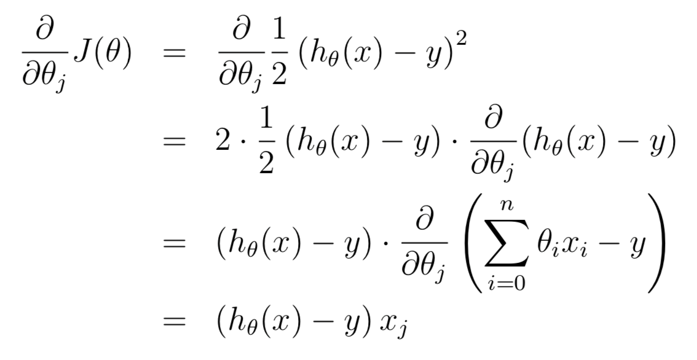

Starting gradient descent...
Initial Error at theta_1 = 0 and theta_0 = 0 is error = 3340.6078047778346
theta_1=0.37006019978298377,theta_0=0.008165626840402687
theta_1=0.6639444116588645,theta_0=0.014653851667769197
theta_1=0.897333260875602,theta_0=0.01980996324062744
theta_1=1.0826795575267731,theta_0=0.023908173541561106
theta_1=1.2298727337475444,theta_0=0.027166248743187685
theta_1=1.3467665082745819,theta_0=0.02975712842856135
theta_1=1.439597932654589,theta_0=0.031818153025846216
theta_1=1.5133201779012695,theta_0=0.0334583918000144
theta_1=1.5718668179008233,theta_0=0.03476446239687186
theta_1=1.6183617107787593,theta_0=0.03580515244936802
theta_1=1.6552856767435256,theta_0=0.03663508983849364
theta_1=1.6846088657377158,theta_0=0.037297657440698774
theta_1=1.7078958775590452,theta_0=0.03782730788227882
theta_1=1.726389243282983,theta_0=0.03825140180770406
theta_1=1.7410757222557622,theta_0=0.03859166774528499
theta_1=1.7527389520270582,theta_0=0.03886536146335894
theta_1=1.762

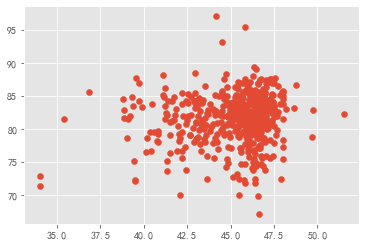

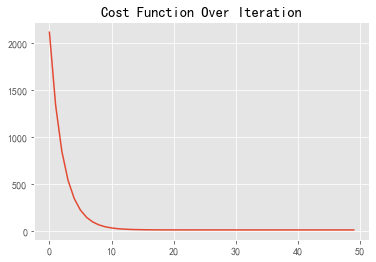

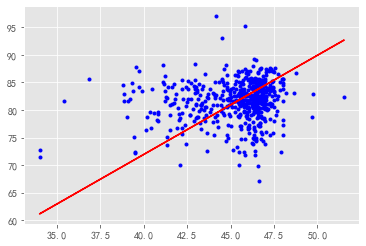

In [12]:
# Import Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
 
fig,ax = plt.subplots()
ax.scatter(x,y)
 
def cost_Function(theta_1,theta_0,x,y):
    return sum(((theta_1*x + theta_0) - y)**2)/(2*len(x))
 
def gradientDescent(x,y,theta_1,theta_0,alpha,iters):
    
    # n: Number of items in a row
    n = len(x)
    a_0 = 2e9
    cutoff=1e-6
    # Array to store values of error for analysis
    hist = []
    # Perform Gradient Descent for iters
    for _ in range(iters):
        # Perform Gradient Descent
        # Initialize Values of Gradients
        gradient_1 = 0
        gradient_0 = 0
        for i in range(len(x)):
            gradient_1 += (1/n) * x[i] * ((theta_1*x[i] + theta_0) - y[i])
            gradient_0 += (1/n) * ((theta_1*x[i] + theta_0) - y[i])
        theta_1 = theta_1 - (alpha*gradient_1)
        theta_0 = theta_0 - (alpha*gradient_0)
        print(f'theta_1={theta_1},theta_0={theta_0}')
        # Calculate the change in error with new values of "theta_1" and "theta_0"
        a = cost_Function(theta_1,theta_0,x,y)
        if abs(a-a_0) < cutoff:
           break
        hist.append(a)
        a_0 = a
    return [theta_1,theta_0,hist]
 
 
# Learning Rate
# lr = 0.001
lr = 1e-4
initial_theta_1 = 0
initial_theta_0 = 0
# Number of Iterations
iterations = 50
print("Starting gradient descent...")
 
print("Initial Error at theta_1 = {0} and theta_0 = {1} is error = {2}".format
      (initial_theta_1, initial_theta_0, 
       cost_Function(initial_theta_1, initial_theta_0, x, y)))
 
 
[theta_1,theta_0,hist] = gradientDescent(x, y, initial_theta_1, initial_theta_0, lr, iterations)
 
print('Values obtained after {0} iterations are theta_1 = {1} and theta_0 = {2}'.format(iterations,theta_1,theta_0))
 
fig,ax = plt.subplots()
ax.plot(hist)
ax.set_title('Cost Function Over Iteration')

fig,ax = plt.subplots()
ax.plot(x,y,'b.')
ax.plot(x,theta_1*x+theta_0,'r')

在Python中，实现线性回归其实有现成的包：Sklearn。
Scikit-learn(Sklearn) 实现线性回归+最小二乘法
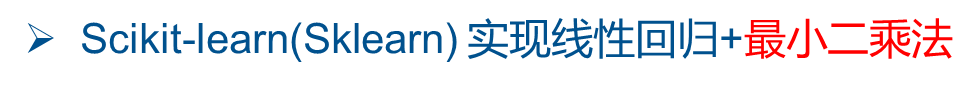

In [22]:
import numpy as np
from sklearn import linear_model  #调sklearn包中的线性回归
from sklearn.metrics import mean_squared_error, r2_score #评估指标
from sklearn.model_selection import train_test_split
reg = linear_model.LinearRegression() #实例化对象

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.25,random_state=2022)
# 将训练数据特征换成二维数组xx行*1列
x_train=x_train.values.reshape(-1,1)
# 将测试数据特征换成二维数组xx行*1列
x_test=x_test.values.reshape(-1,1)
reg.fit(x_train,y_train) #使用训练集训练模型
y_pred = reg.predict(x_test) #使用测试集做预测
print('Coefficients: \n', reg.coef_) # 打印参数即前面讲的𝜃1
print('Intercept: \n', reg.intercept_) # 打印参数即前面讲的𝜃0
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred)) #预测均方差
print('Coefficient of determination: %.2f'% r2_score(y_test, y_pred))  #r^2


Coefficients: 
 [0.18816516]
Intercept: 
 73.02527577070684
Mean squared error: 10.95
Coefficient of determination: 0.02


# Scikit-learn(Sklearn) 实现线性回归+梯度下降法

In [23]:
from sklearn.linear_model import SGDRegressor  #调sklearn包中的梯度下降回归
from sklearn.metrics import mean_squared_error, r2_score #评估指标
gd = SGDRegressor(loss="huber", penalty="l2", max_iter=100) #实例化对象
# X_train,y_train = x,y 
gd.fit(x_train,y_train) #使用训练集训练模型
y_pred = gd.predict(x_test) #使用测试集做预测
print('Coefficients: \n', gd.coef_) # 打印参数即前面讲的𝜃
print('Intercept: \n', gd.intercept_) # 打印参数即前面讲的𝜃0
print('Mean squared error: %.2f'% mean_squared_error(y_test, y_pred)) #预测均方差
print('Coefficient of determination: %.2f'% r2_score(y_test, y_pred))  #r^2


Coefficients: 
 [1.77918032]
Intercept: 
 [0.05677834]
Mean squared error: 21.13
Coefficient of determination: -0.89
